In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight/resourcemanager.zip"

extract_path = "/content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed")
print("\nExtracted files/folders:")

for item in os.listdir(extract_path):
    print(item)

✅ Extraction completed

Extracted files/folders:
resourcemanager.zip
resourcemanager


In [ ]:
import numpy as np
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from pathlib import Path
from google.colab import userdata

**1. Provide the path of java files and load their source code into a list**

In [ ]:
from pathlib import Path

SOURCE_CODE_DIR = Path("/content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight/resourcemanager")
OUTPUT_DIR = Path(
    "/content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight/output"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
files_list = []
# Reloading files from the MapReduce directory
for file_path in SOURCE_CODE_DIR.rglob('*.java'):
    if file_path.is_file():
        with open(file_path, 'r', encoding='utf-8') as f:
            files_list.append(f.read())

**2. Retrieve the Hugging Face token securely from Colab's "Secrets" tab (the key icon on the left).**

In [ ]:
try:
    hf_token = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    print("WARNING: 'HF_TOKEN' not found in Colab Secrets.")
    hf_token = None

**3. Hardware optimization (Quantization)**

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # What is loaded in 4 bit? why?
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

In [ ]:
# 1. Install dependencies.
# IMPORTANT: Restart session (Runtime > Restart session) after this finishes.
!pip install -U bitsandbytes>=0.46.1 accelerate

**4. Generate embeddings**

In [ ]:
embedding_model_name = "jinaai/jina-code-embeddings-0.5b"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(embedding_model_name, token=hf_token)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    # Attempting 4-bit loading
    model = AutoModel.from_pretrained(
        embedding_model_name,
        token=hf_token,
        quantization_config=bnb_config,
        device_map="auto"
    )
    print("Model loaded successfully with 4-bit quantization.")
except Exception as e:
    print(f"Quantization failed or bitsandbytes not found: {e}")
    print("Falling back to standard loading...")
    model = AutoModel.from_pretrained(embedding_model_name, token=hf_token)
    model.to(device)

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Model loaded successfully with 4-bit quantization.


**5. Construct the semantic similarity matrix**

In [ ]:
def embed_source_code(code_files):
    embeddings = []
    # Ensure model is in eval mode and correct dtype
    model.eval()

    for code in code_files:
        # Max length 512
        inputs = tokenizer(code, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

        with torch.no_grad():
            # We force the model to compute in float32 if on CPU or if BFloat16 is unsupported
            outputs = model(**inputs)
            # Take the mean of the token embeddings
            # Ensure we are working with float32 for the mean calculation to avoid the BFloat16 error
            code_embedding = outputs.last_hidden_state.to(torch.float32).mean(dim=1).squeeze().cpu().numpy()
        embeddings.append(code_embedding)
    return np.array(embeddings)

In [ ]:
print(f"Number of files found: {len(files_list)}")

Number of files found: 749


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Initialize with zeros to prevent NameErrors in later cells
global semantic_matrix
semantic_matrix = np.zeros((len(files_list), len(files_list)))

# Check if function exists in globals
if 'embed_source_code' in globals() and len(files_list) > 0:
    print(f"Generating embeddings for {len(files_list)} files...")
    try:
        embeddings_array = embed_source_code(files_list)
        if embeddings_array is not None and len(embeddings_array) > 0:
            semantic_matrix = cosine_similarity(embeddings_array)
            print(f"Semantic similarity matrix constructed: {semantic_matrix.shape}")
    except Exception as e:
        print(f"Error during embedding generation: {e}")
else:
    print("CRITICAL: 'embed_source_code' function not found. Please ensure you have executed cell k3zp8OnDD4re before running this cell.")

Generating embeddings for 749 files...
Semantic similarity matrix constructed: (749, 749)


**6. Construct the structural similarity matrix**

In [ ]:
import re
import numpy as np
from pathlib import Path

def get_full_class_name(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
        package_match = re.search(r'^\s*package\s+([^;]+);', content, re.MULTILINE)
        package = package_match.group(1).strip() if package_match else ""
        class_name = Path(file_path).stem
        return f"{package}.{class_name}" if package else class_name

full_class_names = [get_full_class_name(p) for p in SOURCE_CODE_DIR.rglob('*.java') if p.is_file()]
num_files = len(full_class_names)
struct_matrix_raw = np.zeros((num_files, num_files))

dependencies = {}
rsf_path = "/content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight/filtered_rsf.rsf"

if not Path(rsf_path).exists():
    print(f"CRITICAL ERROR: {rsf_path} not found. Please upload the RSF file to the /content/ folder.")
else:
    try:
        with open(rsf_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 3 and parts[0] == 'depends':
                    source, target = parts[1], parts[2]
                    if source not in dependencies: dependencies[source] = set()
                    dependencies[source].add(target)

        for i in range(num_files):
            for j in range(i, num_files):
                set_i = dependencies.get(full_class_names[i], set())
                set_j = dependencies.get(full_class_names[j], set())
                common_count = len(set_i.intersection(set_j))
                struct_matrix_raw[i, j] = struct_matrix_raw[j, i] = common_count

        print(f"Structural matrix constructed. Shape: {struct_matrix_raw.shape}")
        print(f"Max overlap found: {struct_matrix_raw.max()}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Structural matrix constructed. Shape: (749, 749)
Max overlap found: 162.0


**7. Normalize the structural matrix**

In [ ]:
# Normalizing the structural matrix to a 0-1 range
max_overlap = struct_matrix_raw.max()
if max_overlap > 0:
    struct_matrix = struct_matrix_raw / max_overlap
else:
    struct_matrix = struct_matrix_raw

# Diagonals represent a file's similarity to itself, which is always 1.0
np.fill_diagonal(struct_matrix, 1.0)

print(f"Structural matrix normalized. Max value: {struct_matrix.max()}")

Structural matrix normalized. Max value: 1.0


**8. Combine the two matrices into one similarity matrix then apply complement.**

In [ ]:
# ALPHA dictates the weight of structural vs. semantic data.
# 0.5 gives equal weight to both dependency structure and code meaning.
ALPHA = 0.5
combined_similarity = (ALPHA * struct_matrix) + ((1 - ALPHA) * semantic_matrix)

# Invert similarity to get distance (Clustering algorithms use distance)
distance_matrix = 1.0 - combined_similarity

# Ensure diagonal is exactly 0 (distance to self)
np.fill_diagonal(distance_matrix, 0)

print("Combined distance matrix calculated successfully.")

Combined distance matrix calculated successfully.


**9. Apply clustering**

In [ ]:
print(distance_matrix)

[[0.         0.53158081 0.59935072 ... 0.72168407 0.62909818 0.61945343]
 [0.53158081 0.         0.59509736 ... 0.70899272 0.615592   0.59778076]
 [0.59935072 0.59509736 0.         ... 0.72094584 0.65338081 0.65725088]
 ...
 [0.72168407 0.70899272 0.72094584 ... 0.         0.72399688 0.67411941]
 [0.62909818 0.615592   0.65338081 ... 0.72399688 0.         0.63000584]
 [0.61945343 0.59778076 0.65725088 ... 0.67411941 0.63000584 0.        ]]


In [ ]:
# Final clustering for Week 3
TARGET_NUM_CLUSTERS = 10
clusterer = AgglomerativeClustering(n_clusters=TARGET_NUM_CLUSTERS, metric='precomputed', linkage='complete')
clusters = clusterer.fit_predict(distance_matrix)

print(f"Clustering complete! {len(clusters)} MapReduce files grouped into {TARGET_NUM_CLUSTERS} clusters.")

Clustering complete! 749 MapReduce files grouped into 10 clusters.


**10. Visulizations**

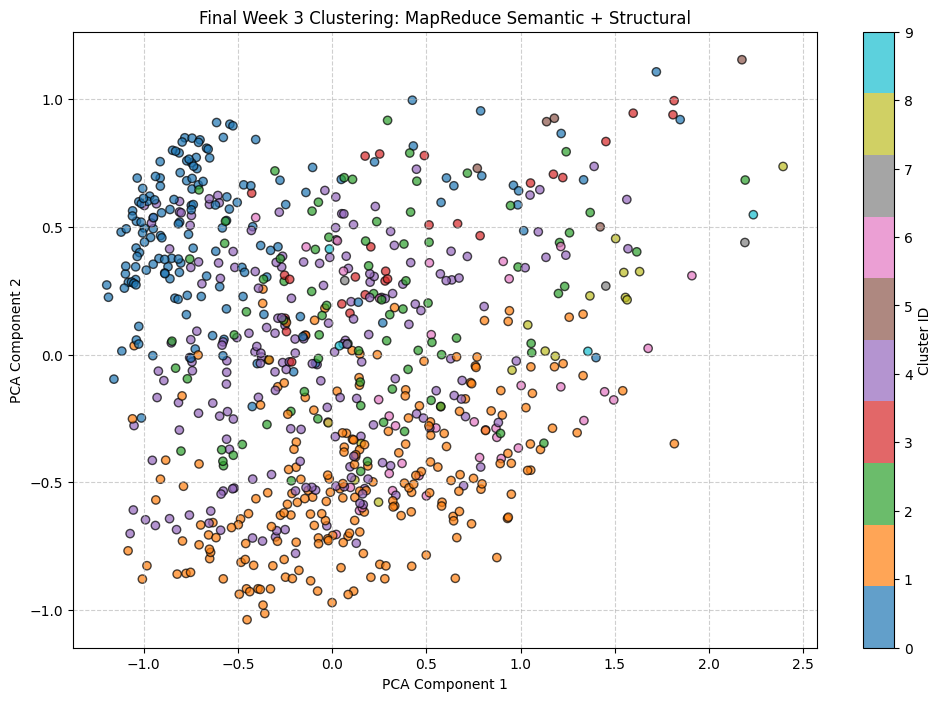

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Visualization using PCA to project the combined distance matrix into 2D
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(distance_matrix)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=clusters, cmap='tab10', alpha=0.7, edgecolors='k')
plt.title('Final Week 3 Clustering: Hadoop Yarn')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

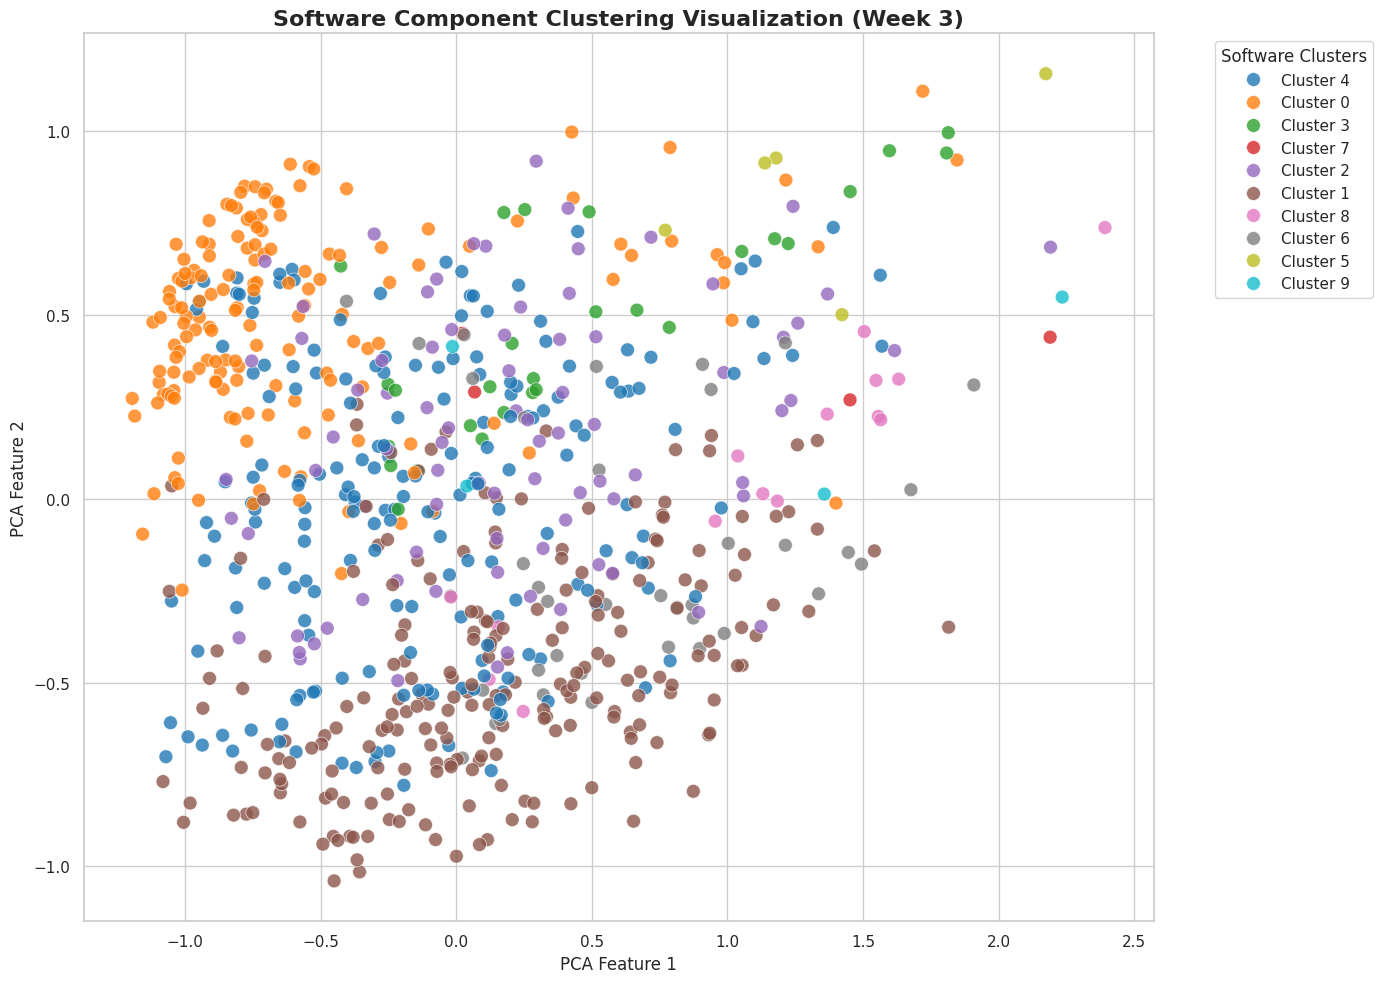

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a more readable dataframe for plotting
plot_df = pd.DataFrame({
    'x': reduced_data[:, 0],
    'y': reduced_data[:, 1],
    'Cluster': [f'Cluster {c}' for c in clusters]
})

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 10))

# Create the scatter plot with a legend
scatter_plot = sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    hue='Cluster',
    palette='tab10',
    s=100,
    alpha=0.8,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Software Component Clustering Visualization (Week 3)', fontsize=16, fontweight='bold')
plt.xlabel('PCA Feature 1', fontsize=12)
plt.ylabel('PCA Feature 2', fontsize=12)

# Move legend to the side for better visibility
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Software Clusters')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Aligning lengths to avoid ValueError
min_length = min(len(full_class_names), len(clusters))

# Create a mapping of File Name to Cluster ID
results_df = pd.DataFrame({
    'Full_Class_Name': full_class_names[:min_length],
    'Cluster_ID': clusters[:min_length]
})

# Save to the output directory
output_file = OUTPUT_DIR / "clustering_results.csv"
results_df.to_csv(output_file, index=False)

print(f"Results saved to: {output_file}")
print(f"Aligned to {min_length} files.")
display(results_df.head())

Results saved to: /content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight/output/clustering_results.csv
Aligned to 749 files.


,Full_Class_Name,Cluster_ID
0,org.apache.hadoop.yarn.server.resourcemanager....,4
1,org.apache.hadoop.yarn.server.resourcemanager....,4
2,org.apache.hadoop.yarn.server.resourcemanager....,4
3,org.apache.hadoop.yarn.server.resourcemanager....,4
4,org.apache.hadoop.yarn.server.resourcemanager....,4


In [ ]:
# Define the output path for the RSF file
rsf_output_path = OUTPUT_DIR / "final_clustering_using_ibm-granite.rsf"

# Open file and write clustering results in RSF format
# Format: contain <Cluster_ID> <Full_Class_Name>
with open(rsf_output_path, 'w') as f:
    for _, row in results_df.iterrows():
        f.write(f"contain Cluster_{row['Cluster_ID']} {row['Full_Class_Name']}\n")

print(f"RSF file generated successfully at: {rsf_output_path}")

# Display the first few lines of the generated RSF
!head -n 5 {rsf_output_path}

RSF file generated successfully at: /content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight/output/final_clustering_using_ibm-granite.rsf
contain Cluster_4 org.apache.hadoop.yarn.server.resourcemanager.ActiveStandbyElectorBasedElectorService
contain Cluster_4 org.apache.hadoop.yarn.server.resourcemanager.AdminService
contain Cluster_4 org.apache.hadoop.yarn.server.resourcemanager.AMSProcessingChain
contain Cluster_4 org.apache.hadoop.yarn.server.resourcemanager.ApplicationMasterService
contain Cluster_4 org.apache.hadoop.yarn.server.resourcemanager.ClientRMService


### Experiment: Adjust Hyperparameters
Use this cell to tweak the balance between structure and semantics, or change the granularity of the clusters.

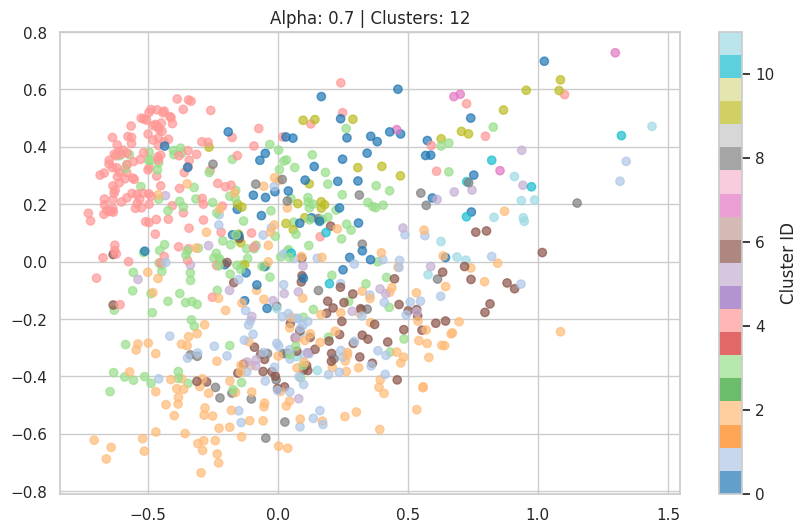

In [ ]:
# @title Clustering Experimentation { run: "auto" }
NEW_ALPHA = 0.7 # @param {type:"slider", min:0, max:1, step:0.1}
NEW_TARGET_CLUSTERS = 12 # @param {type:"slider", min:2, max:30, step:1}

# 1. Re-calculate distance matrix
combined_sim = (NEW_ALPHA * struct_matrix) + ((1 - NEW_ALPHA) * semantic_matrix)
dist_mat = 1.0 - combined_sim
np.fill_diagonal(dist_mat, 0)

# 2. Re-cluster
new_clusterer = AgglomerativeClustering(n_clusters=NEW_TARGET_CLUSTERS, metric='precomputed', linkage='complete')
new_clusters = new_clusterer.fit_predict(dist_mat)

# 3. Visualize the change
pca = PCA(n_components=2)
coords = pca.fit_transform(dist_mat)

plt.figure(figsize=(10, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=new_clusters, cmap='tab20', alpha=0.7)
plt.title(f'Alpha: {NEW_ALPHA} | Clusters: {NEW_TARGET_CLUSTERS}')
plt.colorbar(label='Cluster ID')
plt.show()

## Automated Multi-Model & Hyperparameter Evaluation
This section automates the generation of results for both IBM Granite and Jina AI models across a range of Alpha and Cluster parameters.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import shutil
import traceback
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering

from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer


# ==========================================================
# CONFIGURATION
# ==========================================================

MODELS = [
    "nomic-ai/CodeRankEmbed",
    "jinaai/jina-code-embeddings-0.5b"
]

ALPHAS = [0.3, 0.5, 0.7]
CLUSTERS_LIST = [8, 12, 16]

BASE_OUTPUT = Path(
    "/content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight/experiment_results"
)

BASE_OUTPUT.mkdir(parents=True, exist_ok=True)

print("Results will be saved in:")
print(BASE_OUTPUT)

# Reduce file size before embedding
MAX_CHARS = 4000


# ==========================================================
# EMBEDDING GENERATION
# ==========================================================

def generate_embeddings(model_name, files_list):

    print(f"\nLoading model: {model_name}")

    trimmed_files = [
        code[:MAX_CHARS]
        for code in files_list
    ]

    # =====================================================
    # NOMIC CODERANK
    # =====================================================
    if model_name == "nomic-ai/CodeRankEmbed":

        model = SentenceTransformer(
            model_name,
            trust_remote_code=True,
            token=hf_token,
            device="cpu"
        )

        embeddings = model.encode(
            trimmed_files,
            batch_size=1,
            show_progress_bar=True,
            convert_to_numpy=True
        )

        del model
        gc.collect()

        return np.array(embeddings)

    # =====================================================
    # JINA MODEL
    # =====================================================
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True,
        token=hf_token
    )

    model = AutoModel.from_pretrained(
        model_name,
        trust_remote_code=True,
        token=hf_token
    ).to(device)

    model.eval()

    embeddings = []

    total_files = len(trimmed_files)

    for idx, code in enumerate(trimmed_files):

        if idx % 10 == 0:
            print(f"Embedding {idx}/{total_files}")

        inputs = tokenizer(
            code,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():

            outputs = model(**inputs)

            embedding = (
                outputs.last_hidden_state
                .mean(dim=1)
                .squeeze()
                .cpu()
                .numpy()
            )

        embeddings.append(embedding)

        del inputs
        del outputs

        torch.cuda.empty_cache()

    del model
    gc.collect()

    torch.cuda.empty_cache()

    return np.array(embeddings)


# ==========================================================
# MAIN EXPERIMENT
# ==========================================================

def run_full_pipeline():

    if BASE_OUTPUT.exists():
        shutil.rmtree(BASE_OUTPUT)

    BASE_OUTPUT.mkdir(
        parents=True,
        exist_ok=True
    )

    for model_name in MODELS:

        print("\n" + "=" * 80)
        print(f"PROCESSING MODEL: {model_name}")
        print("=" * 80)

        try:

            embeddings = generate_embeddings(
                model_name,
                files_list
            )

            print("Embedding Shape:")
            print(embeddings.shape)

            semantic_matrix = cosine_similarity(
                embeddings
            )

            model_folder = (
                BASE_OUTPUT /
                model_name.split("/")[-1]
            )

            model_folder.mkdir(
                parents=True,
                exist_ok=True
            )

            for alpha in ALPHAS:

                for n_clusters in CLUSTERS_LIST:

                    print(
                        f"\nRunning Alpha={alpha} "
                        f"Clusters={n_clusters}"
                    )

                    run_dir = (
                        model_folder /
                        f"alpha_{alpha}_clusters_{n_clusters}"
                    )

                    run_dir.mkdir(
                        parents=True,
                        exist_ok=True
                    )

                    # ---------------------------------
                    # HYBRID SIMILARITY
                    # ---------------------------------

                    similarity_matrix = (
                        alpha * struct_matrix
                        + (1 - alpha) * semantic_matrix
                    )

                    distance_matrix = (
                        1.0 - similarity_matrix
                    )

                    np.fill_diagonal(
                        distance_matrix,
                        0
                    )

                    # ---------------------------------
                    # CLUSTERING
                    # ---------------------------------

                    clustering = AgglomerativeClustering(
                        n_clusters=n_clusters,
                        metric="precomputed",
                        linkage="complete"
                    )

                    labels = clustering.fit_predict(
                        distance_matrix
                    )

                    # ---------------------------------
                    # SAVE CSV
                    # ---------------------------------

                    results_df = pd.DataFrame({
                        "Class": full_class_names,
                        "Cluster": labels
                    })

                    results_df.to_csv(
                        run_dir / "results.csv",
                        index=False
                    )

                    # ---------------------------------
                    # SAVE RSF
                    # ---------------------------------

                    with open(
                        run_dir / "output.rsf",
                        "w"
                    ) as f:

                        for _, row in results_df.iterrows():

                            f.write(
                                f"contain "
                                f"Cluster_{row['Cluster']} "
                                f"{row['Class']}\n"
                            )

                    # ---------------------------------
                    # PCA VISUALIZATION
                    # ---------------------------------

                    pca = PCA(
                        n_components=2
                    )

                    coords = pca.fit_transform(
                        distance_matrix
                    )

                    viz_df = pd.DataFrame({
                        "PCA 1": coords[:, 0],
                        "PCA 2": coords[:, 1],
                        "Cluster": [
                            f"C{x}"
                            for x in labels
                        ]
                    })

                    plt.figure(
                        figsize=(12, 8)
                    )

                    sns.set_style(
                        "whitegrid"
                    )

                    sns.scatterplot(
                        data=viz_df,
                        x="PCA 1",
                        y="PCA 2",
                        hue="Cluster",
                        palette="tab20",
                        alpha=0.8
                    )

                    plt.title(
                        f"{model_name}\n"
                        f"Alpha={alpha} | "
                        f"Clusters={n_clusters}"
                    )

                    plt.legend(
                        bbox_to_anchor=(1.05, 1),
                        loc="upper left"
                    )

                    plt.tight_layout()

                    plt.savefig(
                        run_dir /
                        "visualization.png",
                        dpi=300,
                        bbox_inches="tight"
                    )

                    plt.close()

                    print(
                        f"✓ Saved Alpha={alpha}, "
                        f"Clusters={n_clusters}"
                    )

            del embeddings
            del semantic_matrix

            gc.collect()
            torch.cuda.empty_cache()

            print(
                f"\nFinished: {model_name}"
            )

        except Exception:

            print(
                f"\nFAILED MODEL: {model_name}"
            )

            traceback.print_exc()

            continue

    print("\n=================================")
    print("EXPERIMENT COMPLETE")
    print("=================================")

    print("\nGenerated Files:")

    for root, dirs, files in os.walk(BASE_OUTPUT):

        level = root.replace(
            str(BASE_OUTPUT),
            ""
        ).count(os.sep)

        indent = " " * 4 * level

        print(
            f"{indent}{os.path.basename(root)}"
        )

        subindent = " " * 4 * (level + 1)

        for f in files:

            print(
                f"{subindent}{f}"
            )


# ==========================================================
# VERIFY INPUTS
# ==========================================================

print("Files:", len(files_list))
print("Classes:", len(full_class_names))
print("Structure Matrix:", struct_matrix.shape)
print("Device:", device)

# ==========================================================
# RUN
# ==========================================================

run_full_pipeline()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results will be saved in:
/content/drive/MyDrive/01_DSSE_Assignment/Week_3_Light_weight/experiment_results
Files: 749
Classes: 749
Structure Matrix: (749, 749)
Device: cuda

PROCESSING MODEL: nomic-ai/CodeRankEmbed

Loading model: nomic-ai/CodeRankEmbed


Batches:   0%|          | 0/749 [00:00<?, ?it/s]

Embedding Shape:
(749, 768)

Running Alpha=0.3 Clusters=8
✓ Saved Alpha=0.3, Clusters=8

Running Alpha=0.3 Clusters=12
✓ Saved Alpha=0.3, Clusters=12

Running Alpha=0.3 Clusters=16
✓ Saved Alpha=0.3, Clusters=16

Running Alpha=0.5 Clusters=8
✓ Saved Alpha=0.5, Clusters=8

Running Alpha=0.5 Clusters=12
✓ Saved Alpha=0.5, Clusters=12

Running Alpha=0.5 Clusters=16
✓ Saved Alpha=0.5, Clusters=16

Running Alpha=0.7 Clusters=8
✓ Saved Alpha=0.7, Clusters=8

Running Alpha=0.7 Clusters=12
✓ Saved Alpha=0.7, Clusters=12

Running Alpha=0.7 Clusters=16
✓ Saved Alpha=0.7, Clusters=16

Finished: nomic-ai/CodeRankEmbed

PROCESSING MODEL: jinaai/jina-code-embeddings-0.5b

Loading model: jinaai/jina-code-embeddings-0.5b


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Embedding 0/749

FAILED MODEL: jinaai/jina-code-embeddings-0.5b

EXPERIMENT COMPLETE

Generated Files:
experiment_results
    CodeRankEmbed
        alpha_0.3_clusters_8
            results.csv
            output.rsf
            visualization.png
        alpha_0.3_clusters_12
            results.csv
            output.rsf
            visualization.png
        alpha_0.3_clusters_16
            results.csv
            output.rsf
            visualization.png
        alpha_0.5_clusters_8
            results.csv
            output.rsf
            visualization.png
        alpha_0.5_clusters_12
            results.csv
            output.rsf
            visualization.png
        alpha_0.5_clusters_16
            results.csv
            output.rsf
            visualization.png
        alpha_0.7_clusters_8
            results.csv
            output.rsf
            visualization.png
        alpha_0.7_clusters_12
            results.csv
            output.rsf
            visualization.png
       

Traceback (most recent call last):
  File "/tmp/ipykernel_4276/1334067759.py", line 169, in run_full_pipeline
    embeddings = generate_embeddings(
                 ^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_4276/1334067759.py", line 129, in generate_embeddings
    .numpy()
     ^^^^^^^
TypeError: Got unsupported ScalarType BFloat16


### Download Experiment Results
Run the cell below to package all generated files into a ZIP archive and download it to your local machine.

In [ ]:
from google.colab import files
import shutil

# Define the name for the zip file
zip_filename = "clustering_experiment_results"

# Create a zip archive of the results folder
shutil.make_archive(zip_filename, 'zip', BASE_OUTPUT)

# Trigger the download
files.download(f"{zip_filename}.zip")
print(f"Created and downloading {zip_filename}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Created and downloading clustering_experiment_results.zip
